In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

## Agregamos Csv

In [2]:
df = pl.read_csv("../data/raw/social_media_vs_productivity.csv")

## Preparamos la Etl
- Exploracion Inicial y limpieza

In [3]:
print("Informacion del dataset")
print(df)

Informacion del dataset
shape: (30_000, 19)
┌─────┬────────┬────────────┬─────────────┬───┬─────────────┬────────────┬────────────┬────────────┐
│ age ┆ gender ┆ job_type   ┆ daily_socia ┆ … ┆ coffee_cons ┆ days_feeli ┆ weekly_off ┆ job_satisf │
│ --- ┆ ---    ┆ ---        ┆ l_media_tim ┆   ┆ umption_per ┆ ng_burnout ┆ line_hours ┆ action_sco │
│ i64 ┆ str    ┆ str        ┆ e           ┆   ┆ _day        ┆ _per_month ┆ ---        ┆ re         │
│     ┆        ┆            ┆ ---         ┆   ┆ ---         ┆ ---        ┆ f64        ┆ ---        │
│     ┆        ┆            ┆ f64         ┆   ┆ i64         ┆ i64        ┆            ┆ f64        │
╞═════╪════════╪════════════╪═════════════╪═══╪═════════════╪════════════╪════════════╪════════════╡
│ 56  ┆ Male   ┆ Unemployed ┆ 4.18094     ┆ … ┆ 4           ┆ 11         ┆ 21.927072  ┆ 6.336688   │
│ 46  ┆ Male   ┆ Health     ┆ 3.249603    ┆ … ┆ 2           ┆ 25         ┆ 0.0        ┆ 3.412427   │
│ 32  ┆ Male   ┆ Finance    ┆ null        ┆ … ┆

In [4]:
df.head(5)

age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
i64,str,str,f64,str,i64,f64,f64,f64,f64,f64,f64,i64,bool,bool,i64,i64,f64,f64
56,"""Male""","""Unemployed""",4.18094,"""Facebook""",61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,false,false,4,11,21.927072,6.336688
46,"""Male""","""Health""",3.249603,"""Twitter""",59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,true,true,2,25,0.0,3.412427
32,"""Male""","""Finance""",null,"""Twitter""",57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,true,false,3,17,10.322044,2.474944
60,"""Female""","""Unemployed""",null,"""Facebook""",59,6.355027,2.916331,1.774869,6.0,6.052984,1.20454,1,false,false,0,4,23.876616,1.73367
25,"""Male""","""IT""",null,"""Telegram""",66,6.214096,8.868753,null,7.0,5.405706,1.876254,1,false,true,1,30,10.653519,9.69306


In [5]:
df.tail(5)

age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
i64,str,str,f64,str,i64,f64,f64,f64,f64,f64,f64,i64,bool,bool,i64,i64,f64,f64
34,"""Female""","""Health""",1.877297,"""Facebook""",59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,false,false,4,5,21.776927,null
39,"""Male""","""Health""",4.437784,"""Instagram""",46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,false,false,1,29,4.11137,6.155613
42,"""Male""","""Education""",17.724981,"""TikTok""",64,10.915036,8.611005,8.658912,5.0,5.49152,1.224296,10,false,false,1,2,1.888315,6.285237
20,"""Female""","""Education""",3.796634,"""Instagram""",56,6.93741,7.767076,6.895583,8.0,6.816069,0.234483,1,false,false,2,9,12.511871,7.854711
44,"""Male""","""Unemployed""",null,"""Twitter""",70,8.069883,6.311227,5.402726,3.0,6.765248,0.99309,5,false,true,1,4,6.324954,7.38879


In [6]:
print(df.columns)

['age', 'gender', 'job_type', 'daily_social_media_time', 'social_platform_preference', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']


In [7]:
df.dtypes

[Int64,
 String,
 String,
 Float64,
 String,
 Int64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Int64,
 Boolean,
 Boolean,
 Int64,
 Int64,
 Float64,
 Float64]

## Verificamos nulos

In [8]:
null_counts = df.null_count()
print("\nValores nulos por columna:")
for col, count in zip(df.columns, null_counts.row(0)):
    print(f"{col}: {count}")


Valores nulos por columna:
age: 0
gender: 0
job_type: 0
daily_social_media_time: 2765
social_platform_preference: 0
number_of_notifications: 0
work_hours_per_day: 0
perceived_productivity_score: 1614
actual_productivity_score: 2365
stress_level: 1904
sleep_hours: 2598
screen_time_before_sleep: 2211
breaks_during_work: 0
uses_focus_apps: 0
has_digital_wellbeing_enabled: 0
coffee_consumption_per_day: 0
days_feeling_burnout_per_month: 0
weekly_offline_hours: 0
job_satisfaction_score: 2730


### Reemplazar valores nulos con la mediana para columnas numericas 

In [9]:
numeric_cols = [col for col in df.columns if df[col].dtype in [pl.Float64, pl.Int64]]
for col in numeric_cols:
    median_val = df[col].median()
    df = df.with_columns(pl.col(col).fill_null(median_val))

## Análisis de correlación entre uso de redes sociales y productividad

In [10]:
df.describe()

statistic,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
str,f64,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",30000.0,"""30000""","""30000""",30000.0,"""30000""",30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0
"""null_count""",0.0,"""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",41.486867,null,null,3.105353,null,59.958767,6.990792,5.511269,4.9518,5.5449,6.500082,1.024138,4.9922,0.3007,0.2466,1.9993,15.557067,10.360655,4.96364
"""std""",13.835221,null,null,1.977046,null,7.723772,1.997736,1.968287,1.807615,2.77642,1.399175,0.628838,3.173737,null,null,1.410047,9.252956,7.280415,2.022378
"""min""",18.0,"""Female""","""Education""",0.0,"""Facebook""",30.0,0.0,2.000252,0.296812,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",30.0,null,null,1.797754,null,55.0,5.643883,3.858837,3.509361,3.0,5.598944,0.569581,2.0,null,null,1.0,8.0,4.541991,3.528494
"""50%""",41.0,null,null,3.025913,null,60.0,6.990715,5.525005,4.951742,6.0,6.49834,1.006159,5.0,null,null,2.0,16.0,10.013906,4.951049
"""75%""",53.0,null,null,4.219418,null,65.0,8.354706,7.168037,6.396252,8.0,7.398964,1.435779,8.0,null,null,3.0,24.0,15.300393,6.406952
"""max""",65.0,"""Other""","""Unemployed""",17.973256,"""Twitter""",90.0,12.0,8.999376,9.846258,10.0,10.0,3.0,10.0,1.0,1.0,10.0,31.0,40.964769,10.0


In [11]:
correlation = df.select([
    pl.corr("daily_social_media_time", "actual_productivity_score").alias("correlation")
])
print("\nCorrelación entre tiempo en redes sociales y productividad real:")
print(correlation)


Correlación entre tiempo en redes sociales y productividad real:
shape: (1, 1)
┌─────────────┐
│ correlation │
│ ---         │
│ f64         │
╞═════════════╡
│ -0.010072   │
└─────────────┘


## Análisis por plataforma de redes sociales

In [12]:
platform_productivity = df.group_by("social_platform_preference").agg([
    pl.mean("actual_productivity_score").alias("avg_productivity"),
    pl.count().alias("count")
]).sort("avg_productivity", descending=True)

print("\nProductividad promedio por plataforma de redes sociales:")
print(platform_productivity)


Productividad promedio por plataforma de redes sociales:
shape: (5, 3)
┌────────────────────────────┬──────────────────┬───────┐
│ social_platform_preference ┆ avg_productivity ┆ count │
│ ---                        ┆ ---              ┆ ---   │
│ str                        ┆ f64              ┆ u32   │
╞════════════════════════════╪══════════════════╪═══════╡
│ TikTok                     ┆ 4.976946         ┆ 6096  │
│ Twitter                    ┆ 4.970837         ┆ 5964  │
│ Instagram                  ┆ 4.954714         ┆ 6006  │
│ Facebook                   ┆ 4.929769         ┆ 5921  │
│ Telegram                   ┆ 4.926207         ┆ 6013  │
└────────────────────────────┴──────────────────┴───────┘


C:\Users\anoni\AppData\Local\Temp\ipykernel_11936\3554206112.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")


## Visualización: Tiempo en redes sociales vs productividad

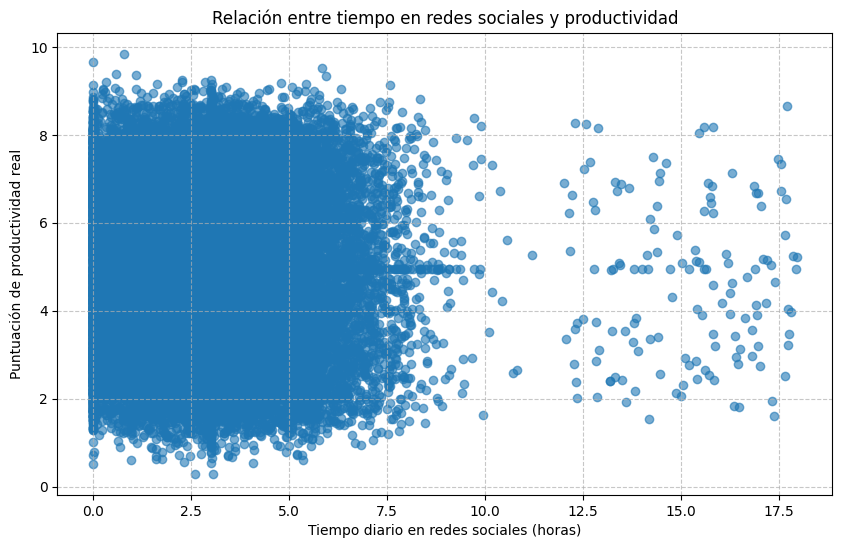

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df["daily_social_media_time"].to_numpy(), df["actual_productivity_score"].to_numpy(), alpha=0.6)
plt.title("Relación entre tiempo en redes sociales y productividad")
plt.xlabel("Tiempo diario en redes sociales (horas)")
plt.ylabel("Puntuación de productividad real")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Linea de tendencia

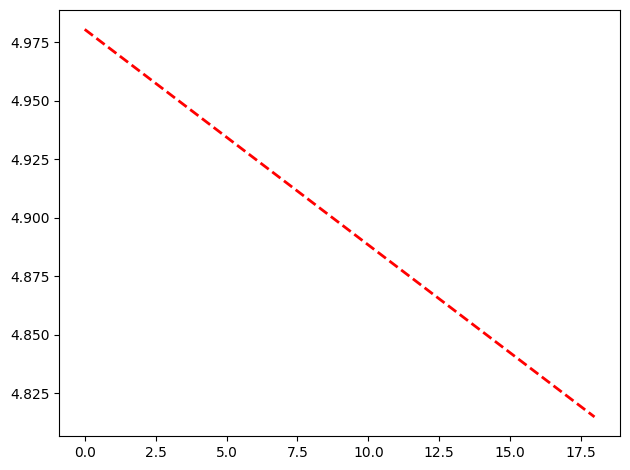

In [14]:
x = df["daily_social_media_time"].to_numpy()
y = df["actual_productivity_score"].to_numpy()
mask = ~np.isnan(x) & ~np.isnan(y)
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
plt.plot(np.sort(x[mask]), p(np.sort(x[mask])), "r--", linewidth=2)

plt.tight_layout()
plt.show()

## Analisis de factores que afectan la productividad 

In [16]:
factors = ["daily_social_media_time", "number_of_notifications", "sleep_hours", 
           "screen_time_before_sleep", "breaks_during_work", "stress_level"]

In [21]:
correlations = []

for factor in factors:
    corr = df.select([
        pl.corr(factor, "actual_productivity_score").alias("correlation")
    ])
    correlations.append((factor, corr))

correlations.sort(key=lambda x: x[1].to_numpy()[0], reverse=True)
print("\nCorrelación de factores con la productividad real:")



Correlación de factores con la productividad real:


## Analisis de uso de aplicaciones de enfoque 

In [27]:
focus_app_analysis = df.group_by("uses_focus_apps").agg([
    pl.mean("actual_productivity_score").alias("avg_productivity"),
    pl.mean("daily_social_media_time").alias("avg_social_media_time"),
    pl.count().alias("count")
])

print("\nProductividad según uso de aplicaciones de enfoque:")
print(focus_app_analysis)

C:\Users\anoni\AppData\Local\Temp\ipykernel_11936\1655439810.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")



Productividad según uso de aplicaciones de enfoque:
shape: (2, 4)
┌─────────────────┬──────────────────┬───────────────────────┬───────┐
│ uses_focus_apps ┆ avg_productivity ┆ avg_social_media_time ┆ count │
│ ---             ┆ ---              ┆ ---                   ┆ ---   │
│ bool            ┆ f64              ┆ f64                   ┆ u32   │
╞═════════════════╪══════════════════╪═══════════════════════╪═══════╡
│ true            ┆ 4.949093         ┆ 3.090798              ┆ 9021  │
│ false           ┆ 4.952964         ┆ 3.111612              ┆ 20979 │
└─────────────────┴──────────────────┴───────────────────────┴───────┘


## Recomendaciones basadas en el análisis

In [ ]:
print("1. Limpieza de datos: Reemplazar valores nulos con medianas o medias según distribución")
print("2. Transformaciones: Crear categorías de usuarios según tiempo de uso de redes sociales")
print("3. Crear métricas compuestas: Índice de distracción digital combinando tiempo en redes y notificaciones")
print("4. Normalizar puntuaciones de productividad para comparaciones más justas")
print("5. Crear variables derivadas como ratio de productividad percibida vs real")


Recomendaciones para la ETL:
1. Limpieza de datos: Reemplazar valores nulos con medianas o medias según distribución
2. Transformaciones: Crear categorías de usuarios según tiempo de uso de redes sociales
3. Crear métricas compuestas: Índice de distracción digital combinando tiempo en redes y notificaciones
4. Normalizar puntuaciones de productividad para comparaciones más justas
5. Crear variables derivadas como ratio de productividad percibida vs real
